# LESSON 6.5: Inverse Filtering and Degradation Function Estimation
## Image Restoration

In this lesson:
- Linear, position-invariant degradation model
- Estimating the degradation function: observation, experimentation, modeling
- Common degradation models: atmospheric turbulence, motion blur
- Inverse filtering: theory and limitations
- Truncated inverse filtering to reduce noise amplification
- Pseudoinverse filtering

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Linear, Position-Invariant Degradation

Recall the degradation model:

$$G(u,v) = H(u,v) \cdot F(u,v) + N(u,v)$$

The key assumption is that $H$ is **Linear and Position-Invariant (LPI)**:

### Linearity:
$$H\{a \cdot f_1(x,y) + b \cdot f_2(x,y)\} = a \cdot H\{f_1\} + b \cdot H\{f_2\}$$

### Position-Invariance:
$$H\{f(x - x_0, y - y_0)\} = g(x - x_0, y - y_0)$$

If the degradation shifts, the output shifts by the same amount (the PSF is the same everywhere).

### Why these assumptions matter:
- **Linearity + Position-invariance** → degradation is a **convolution**
- Convolution in spatial domain = multiplication in frequency domain
- This enables **frequency domain restoration** (dividing instead of deconvolving)

In [2]:
# Helper functions

def create_test_image(size=256):
    """Create a synthetic biomedical phantom image."""
    img = np.ones((size, size), dtype=np.float64) * 30
    Y, X = np.mgrid[0:size, 0:size]
    cx, cy = size // 2, size // 2
    
    body = ((X - cx) / 100) ** 2 + ((Y - cy) / 80) ** 2 <= 1
    img[body] = 120
    organ1 = ((X - cx + 30) / 35) ** 2 + ((Y - cy + 10) / 45) ** 2 <= 1
    img[organ1] = 170
    organ2 = ((X - cx - 35) / 25) ** 2 + ((Y - cy - 15) / 30) ** 2 <= 1
    img[organ2] = 80
    for (sx, sy, sr) in [(cx-20, cy+30, 5), (cx+40, cy-25, 4), (cx-50, cy-20, 3)]:
        spot = (X - sx) ** 2 + (Y - sy) ** 2 <= sr ** 2
        img[spot] = 240
    for i in range(cy-40, cy+40):
        j = int(cx + 20 * np.sin(2 * np.pi * i / 50))
        if 0 <= j < size and 0 <= i < size:
            img[i, max(0,j-1):min(size,j+2)] = 200
    return img


def compute_psnr(original, restored):
    """Compute PSNR in dB."""
    mse = np.mean((original - restored) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(255.0 ** 2 / mse)


def pad_psf(psf, image_shape):
    """Zero-pad PSF to image size, centering at (0,0) for DFT."""
    padded = np.zeros(image_shape, dtype=np.float64)
    ph, pw = psf.shape
    for i in range(ph):
        for j in range(pw):
            ni = (i - ph // 2) % image_shape[0]
            nj = (j - pw // 2) % image_shape[1]
            padded[ni, nj] = psf[i, j]
    return padded


original = create_test_image(256)
M, N = original.shape
print(f"Test image created: {M}×{N}")

Test image created: 256×256


---
## 2. Estimating the Degradation Function

To restore an image, we must know (or estimate) $H(u,v)$. Three approaches:

### 2.1 Observation (Image-Based Estimation)
- Find a **small, bright subimage** in the degraded image (e.g., a bright point or star)
- This subimage is approximately $H(u,v) \cdot \delta(u,v) = H(u,v)$
- The DFT of the blurred point gives $H(u,v)$ directly

### 2.2 Experimentation
- Image a **known test pattern** (e.g., a point source, resolution target)
- Compare the output with the known input
- $H(u,v) = G(u,v) / F(u,v)$ where $F$ is the known input

### 2.3 Mathematical Modeling
- Use **physics** of the imaging system to derive $H(u,v)$ analytically
- Most common approach in practice

---
## 3. Common Degradation Models

### 3.1 Atmospheric Turbulence Model (Hufnagel & Stanley)

$$H(u,v) = e^{-k(u^2 + v^2)^{5/6}}$$

Where $k$ is the **turbulence severity** parameter:
- Small $k$ (e.g., 0.001): mild turbulence (slight blur)
- Large $k$ (e.g., 0.01): severe turbulence (heavy blur)

### 3.2 Uniform Linear Motion Blur

If the image moves by $(a, b)$ pixels during exposure time $T$:

$$H(u,v) = \frac{T}{\pi(ua + vb)} \sin\left[\pi(ua + vb)\right] e^{-j\pi(ua + vb)}$$

Properties:
- The sinc function creates **zeros** in $H(u,v)$ at regular intervals
- These zeros make inverse filtering impossible at those frequencies
- The direction $(a,b)$ determines the angle of the blur

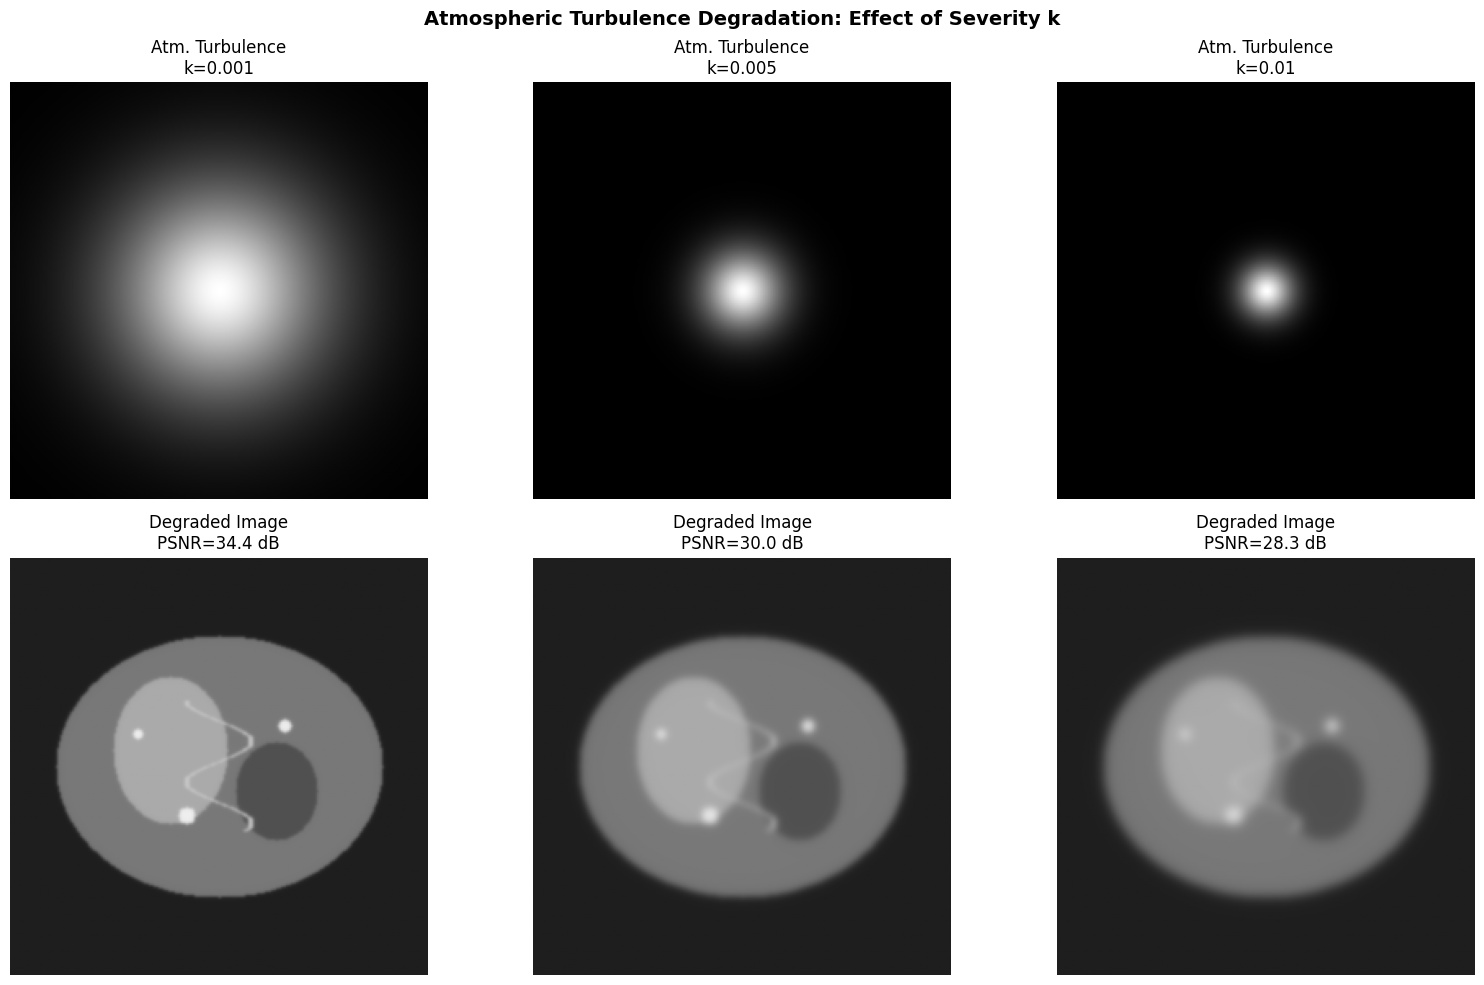

In [3]:
# Implement degradation models

def atmospheric_turbulence_otf(P, Q, k=0.0025):
    """
    Atmospheric turbulence degradation: H(u,v) = exp(-k * (u^2 + v^2)^(5/6))
    
    Parameters:
        P, Q: image dimensions
        k: turbulence severity (larger = more blur)
    Returns:
        H(u,v) centered
    """
    u = np.arange(P) - P/2
    v = np.arange(Q) - Q/2
    U, V = np.meshgrid(u, v, indexing='ij')
    D2 = U**2 + V**2
    H = np.exp(-k * D2**(5/6))
    return H


def motion_blur_otf(P, Q, a=0.1, b=0.0, T=1.0):
    """
    Uniform linear motion blur: H(u,v) = (T/pi(ua+vb)) * sin(pi(ua+vb)) * exp(-j*pi(ua+vb))
    
    Parameters:
        P, Q: image dimensions
        a, b: motion parameters (pixels moved during exposure)
        T: exposure time
    Returns:
        H(u,v) centered (complex)
    """
    u = np.arange(P) - P/2
    v = np.arange(Q) - Q/2
    U, V = np.meshgrid(u, v, indexing='ij')
    
    arg = np.pi * (U * a + V * b)
    # Avoid division by zero
    arg_safe = np.where(np.abs(arg) < 1e-10, 1e-10, arg)
    
    H = (T / arg_safe) * np.sin(arg_safe) * np.exp(-1j * arg_safe)
    # Fix the center (where arg=0, H should be T)
    H[np.abs(arg) < 1e-10] = T
    
    return H


def create_gaussian_psf(size, sigma):
    """Create Gaussian PSF."""
    Y, X = np.mgrid[0:size, 0:size]
    cx, cy = size // 2, size // 2
    psf = np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))
    psf /= psf.sum()
    return psf


# Visualize different degradation models
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Atmospheric turbulence
k_values = [0.001, 0.005, 0.01]
for i, k in enumerate(k_values):
    H = atmospheric_turbulence_otf(M, N, k)
    axes[0, i].imshow(H, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'Atm. Turbulence\nk={k}', fontsize=12)
    axes[0, i].axis('off')
    
    # Apply to image
    F = np.fft.fftshift(np.fft.fft2(original))
    G = H * F
    degraded = np.real(np.fft.ifft2(np.fft.ifftshift(G)))
    degraded = np.clip(degraded, 0, 255)
    
    axes[1, i].imshow(degraded, cmap='gray', vmin=0, vmax=255)
    axes[1, i].set_title(f'Degraded Image\nPSNR={compute_psnr(original, degraded):.1f} dB', fontsize=12)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('H(u,v)', fontsize=12)
axes[1, 0].set_ylabel('Result', fontsize=12)

plt.suptitle('Atmospheric Turbulence Degradation: Effect of Severity k',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

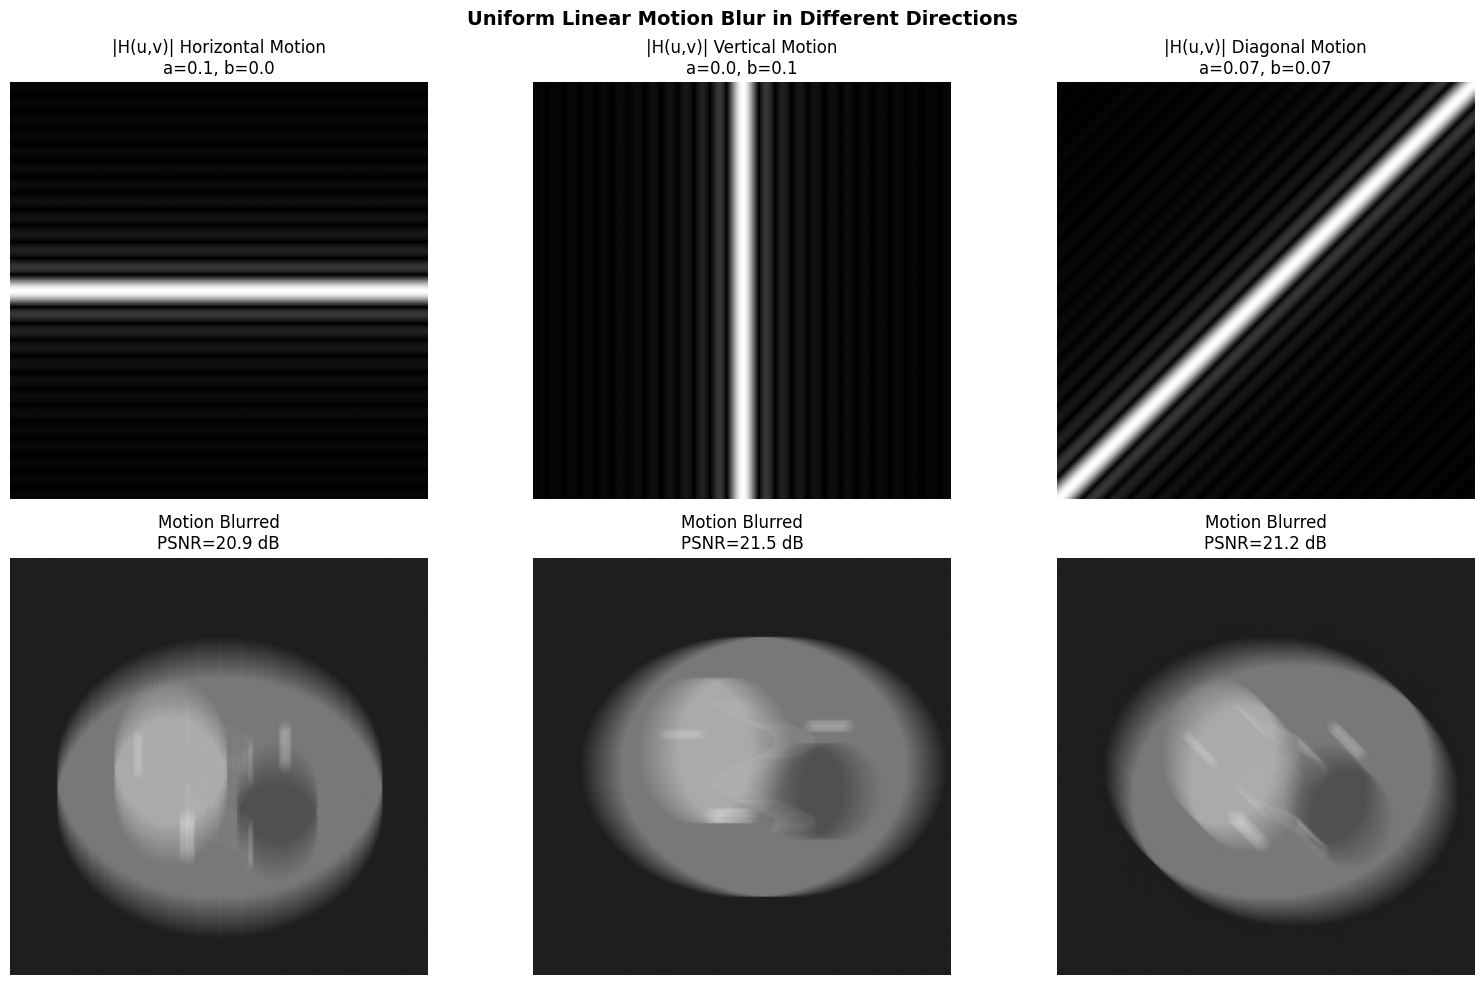

Notice the characteristic STRIPE PATTERN in the motion blur OTF.
The zeros of the sinc function create bands where H(u,v) = 0.
These zeros are perpendicular to the motion direction.


In [4]:
# Motion blur degradation
motion_params = [(0.1, 0.0, 'Horizontal'), (0.0, 0.1, 'Vertical'), (0.07, 0.07, 'Diagonal')]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, (a, b, direction) in enumerate(motion_params):
    H = motion_blur_otf(M, N, a, b)
    
    axes[0, i].imshow(np.abs(H), cmap='gray')
    axes[0, i].set_title(f'|H(u,v)| {direction} Motion\na={a}, b={b}', fontsize=12)
    axes[0, i].axis('off')
    
    F = np.fft.fftshift(np.fft.fft2(original))
    G = H * F
    degraded = np.real(np.fft.ifft2(np.fft.ifftshift(G)))
    degraded = np.clip(degraded, 0, 255)
    
    axes[1, i].imshow(degraded, cmap='gray', vmin=0, vmax=255)
    axes[1, i].set_title(f'Motion Blurred\nPSNR={compute_psnr(original, degraded):.1f} dB', fontsize=12)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('|H(u,v)|', fontsize=12)
axes[1, 0].set_ylabel('Degraded', fontsize=12)

plt.suptitle('Uniform Linear Motion Blur in Different Directions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Notice the characteristic STRIPE PATTERN in the motion blur OTF.")
print("The zeros of the sinc function create bands where H(u,v) = 0.")
print("These zeros are perpendicular to the motion direction.")

---
## 4. Inverse Filtering

The simplest restoration approach: **divide out** the degradation in the frequency domain.

Given: $G(u,v) = H(u,v) \cdot F(u,v) + N(u,v)$

### Naive Inverse Filter:

$$\hat{F}(u,v) = \frac{G(u,v)}{H(u,v)} = F(u,v) + \frac{N(u,v)}{H(u,v)}$$

### The Problem:

The term $\frac{N(u,v)}{H(u,v)}$ is the **noise amplification** term:

- Where $H(u,v)$ is large: noise is suppressed (good)
- Where $H(u,v) \to 0$: noise is amplified to infinity (catastrophic!)

Even tiny amounts of noise become dominant when divided by near-zero values of $H$.

### This is why naive inverse filtering almost always fails in practice.

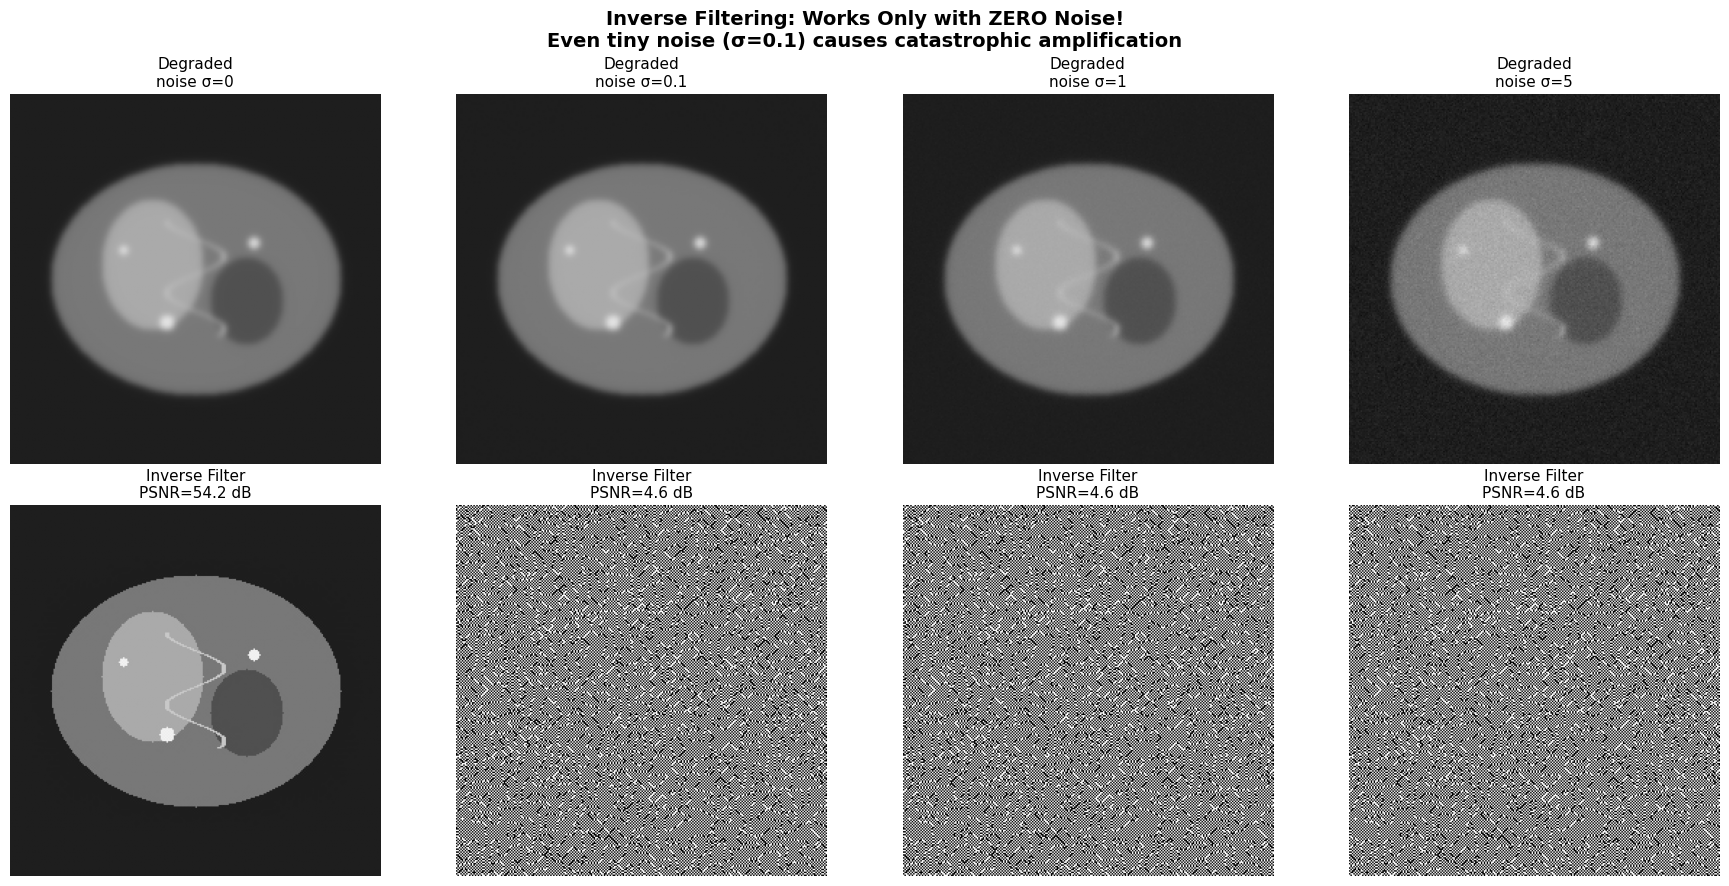

σ=0: Perfect restoration (no noise to amplify)
σ=0.1: Even nearly imperceptible noise destroys the result!
This is the fundamental limitation of inverse filtering.


In [5]:
# Demonstrate inverse filtering failure

# Degrade with atmospheric turbulence
k = 0.005
H_turb = atmospheric_turbulence_otf(M, N, k)
F_original = np.fft.fftshift(np.fft.fft2(original))
G_noiseless = H_turb * F_original

# Add different noise levels
noise_levels = [0, 0.1, 1, 5]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, noise_sigma in enumerate(noise_levels):
    # Create degraded image
    np.random.seed(42)
    degraded_spatial = np.real(np.fft.ifft2(np.fft.ifftshift(G_noiseless)))
    if noise_sigma > 0:
        degraded_spatial += np.random.normal(0, noise_sigma, degraded_spatial.shape)
    degraded_spatial = np.clip(degraded_spatial, 0, 255)
    
    # Apply inverse filter
    G = np.fft.fftshift(np.fft.fft2(degraded_spatial))
    # Inverse filter with small epsilon to prevent division by exactly zero
    H_safe = np.where(np.abs(H_turb) > 1e-10, H_turb, 1e-10)
    F_hat = G / H_safe
    restored = np.real(np.fft.ifft2(np.fft.ifftshift(F_hat)))
    restored = np.clip(restored, 0, 255)
    
    axes[0, i].imshow(degraded_spatial, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(f'Degraded\nnoise σ={noise_sigma}', fontsize=11)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(restored, cmap='gray', vmin=0, vmax=255)
    psnr = compute_psnr(original, restored)
    axes[1, i].set_title(f'Inverse Filter\nPSNR={psnr:.1f} dB', fontsize=11)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Degraded', fontsize=12)
axes[1, 0].set_ylabel('Restored', fontsize=12)

plt.suptitle('Inverse Filtering: Works Only with ZERO Noise!\n'
             'Even tiny noise (σ=0.1) causes catastrophic amplification',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("σ=0: Perfect restoration (no noise to amplify)")
print("σ=0.1: Even nearly imperceptible noise destroys the result!")
print("This is the fundamental limitation of inverse filtering.")

---
## 5. Truncated (Radius-Limited) Inverse Filtering

A practical improvement: **only apply** the inverse filter within a **limited radius** $D_0$ where $H(u,v)$ is large enough:

$$\hat{F}(u,v) = \begin{cases} G(u,v) / H(u,v) & \text{if } D(u,v) \leq D_0 \\ 0 & \text{if } D(u,v) > D_0 \end{cases}$$

### Why this helps:
- At low frequencies (small $D$): $H$ is large, so $G/H$ is safe
- At high frequencies (large $D$): $H \to 0$, so we **don't invert** (set to 0)
- This truncation limits noise amplification at the cost of not restoring high frequencies

### The trade-off:
- Small $D_0$: less noise but more blur (lost high frequencies)
- Large $D_0$: more detail but more noise amplification

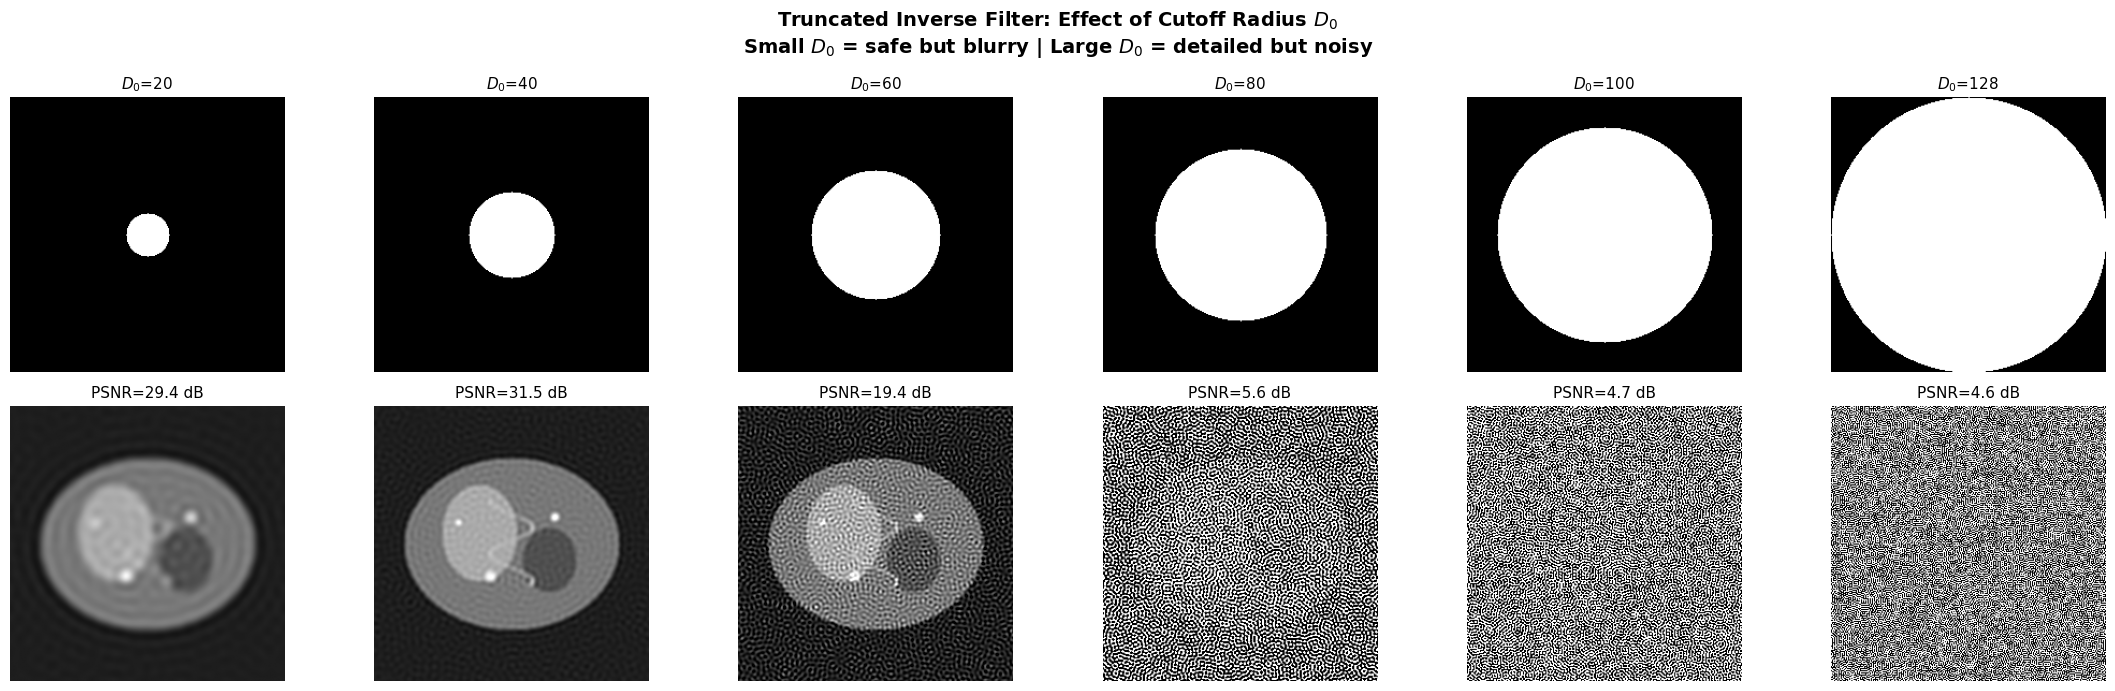

In [6]:
# Truncated inverse filtering

def truncated_inverse_filter(G, H, D0):
    """
    Apply inverse filter only within radius D0.
    
    Parameters:
        G: DFT of degraded image (centered)
        H: degradation OTF (centered)
        D0: maximum radius for inversion
    Returns:
        Restored image
    """
    P, Q = G.shape
    u = np.arange(P) - P/2
    v = np.arange(Q) - Q/2
    U, V = np.meshgrid(u, v, indexing='ij')
    D = np.sqrt(U**2 + V**2)
    
    F_hat = np.zeros_like(G, dtype=complex)
    mask = D <= D0
    H_safe = np.where(np.abs(H) > 1e-10, H, 1e-10)
    F_hat[mask] = G[mask] / H_safe[mask]
    
    restored = np.real(np.fft.ifft2(np.fft.ifftshift(F_hat)))
    return np.clip(restored, 0, 255)


# Degrade with turbulence + noise
k = 0.005
H_turb = atmospheric_turbulence_otf(M, N, k)
F_original = np.fft.fftshift(np.fft.fft2(original))

np.random.seed(42)
degraded = np.real(np.fft.ifft2(np.fft.ifftshift(H_turb * F_original)))
degraded += np.random.normal(0, 2, degraded.shape)
degraded = np.clip(degraded, 0, 255)

G = np.fft.fftshift(np.fft.fft2(degraded))

# Apply truncated inverse filter with different radii
D0_values = [20, 40, 60, 80, 100, 128]

fig, axes = plt.subplots(2, 6, figsize=(22, 7))

for i, D0 in enumerate(D0_values):
    restored = truncated_inverse_filter(G, H_turb, D0)
    psnr = compute_psnr(original, restored)
    
    # Show the inversion mask
    u = np.arange(M) - M/2
    v = np.arange(N) - N/2
    U, V = np.meshgrid(u, v, indexing='ij')
    D = np.sqrt(U**2 + V**2)
    mask = (D <= D0).astype(float)
    
    axes[0, i].imshow(mask, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'$D_0$={D0}', fontsize=11)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(restored, cmap='gray', vmin=0, vmax=255)
    axes[1, i].set_title(f'PSNR={psnr:.1f} dB', fontsize=11)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Inversion Mask', fontsize=12)
axes[1, 0].set_ylabel('Restored', fontsize=12)

plt.suptitle('Truncated Inverse Filter: Effect of Cutoff Radius $D_0$\n'
             'Small $D_0$ = safe but blurry | Large $D_0$ = detailed but noisy',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

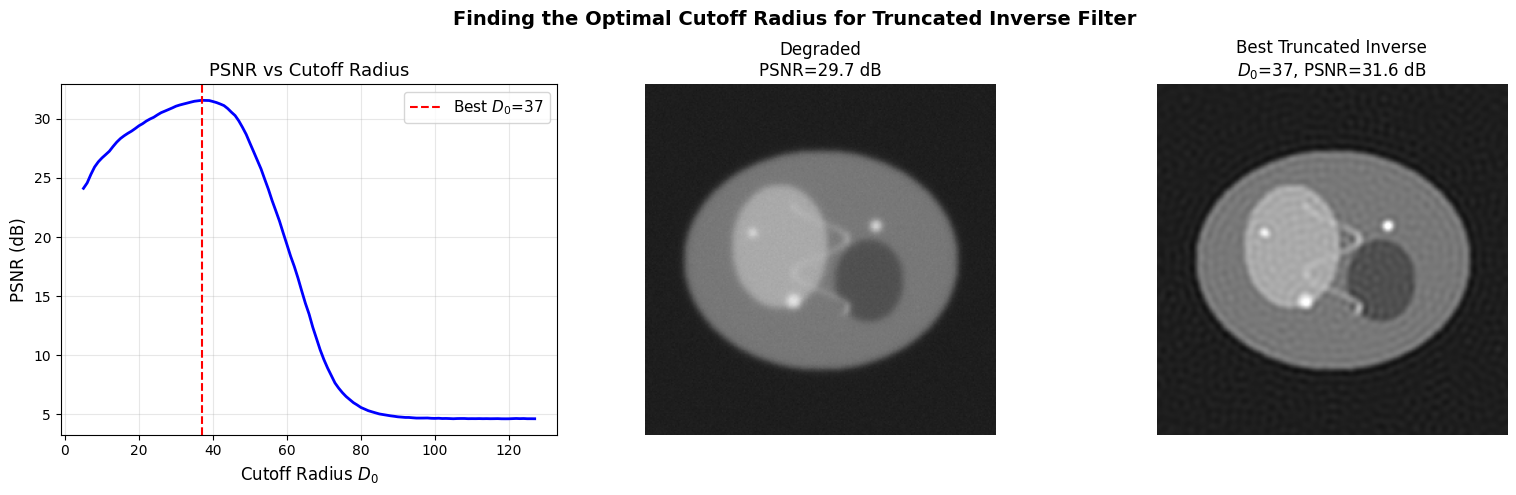

Optimal D0 = 37 gives PSNR = 31.6 dB
This is a clear improvement over the degraded image (29.7 dB)
But finding the optimal D0 requires knowing the original image (not realistic)!

Wiener filter (next lesson) handles this trade-off automatically.


In [7]:
# Find the optimal D0 for truncated inverse filter

D0_range = np.arange(5, 128, 1)
psnr_values = []

for D0 in D0_range:
    restored = truncated_inverse_filter(G, H_turb, D0)
    psnr_values.append(compute_psnr(original, restored))

best_D0 = D0_range[np.argmax(psnr_values)]
best_psnr = max(psnr_values)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(D0_range, psnr_values, 'b-', linewidth=2)
axes[0].axvline(x=best_D0, color='r', linestyle='--', label=f'Best $D_0$={best_D0}')
axes[0].set_xlabel('Cutoff Radius $D_0$', fontsize=12)
axes[0].set_ylabel('PSNR (dB)', fontsize=12)
axes[0].set_title('PSNR vs Cutoff Radius', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Show degraded
axes[1].imshow(degraded, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Degraded\nPSNR={compute_psnr(original, degraded):.1f} dB', fontsize=12)
axes[1].axis('off')

# Show best restoration
best_restored = truncated_inverse_filter(G, H_turb, best_D0)
axes[2].imshow(best_restored, cmap='gray', vmin=0, vmax=255)
axes[2].set_title(f'Best Truncated Inverse\n$D_0$={best_D0}, PSNR={best_psnr:.1f} dB', fontsize=12)
axes[2].axis('off')

plt.suptitle('Finding the Optimal Cutoff Radius for Truncated Inverse Filter',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Optimal D0 = {best_D0} gives PSNR = {best_psnr:.1f} dB")
print(f"This is a clear improvement over the degraded image ({compute_psnr(original, degraded):.1f} dB)")
print("But finding the optimal D0 requires knowing the original image (not realistic)!")
print("\nWiener filter (next lesson) handles this trade-off automatically.")

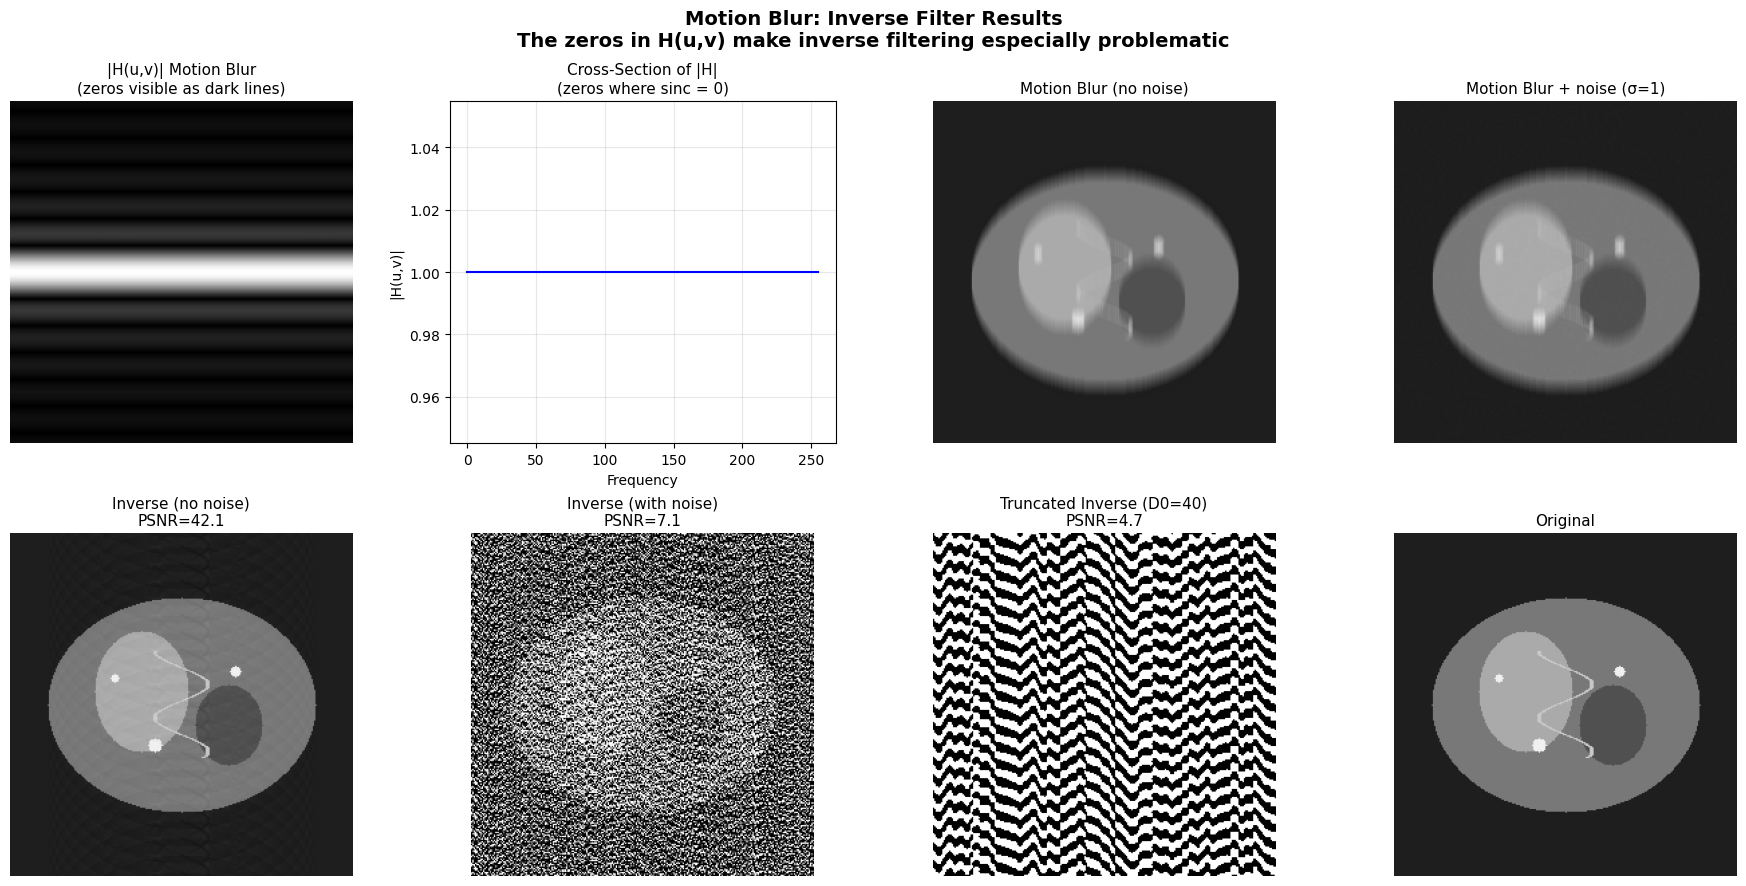

Motion blur has EXACT ZEROS in H(u,v) — inverse is undefined there!
Even the truncated inverse filter cannot recover frequencies at those zeros.
Wiener and CLS filters handle this much better (next lessons).


In [8]:
# Motion blur inverse filtering demonstration

# Create motion-blurred image
H_motion = motion_blur_otf(M, N, a=0.05, b=0.0)
F_orig = np.fft.fftshift(np.fft.fft2(original))

# No noise case
G_clean = H_motion * F_orig
degraded_clean = np.real(np.fft.ifft2(np.fft.ifftshift(G_clean)))
degraded_clean = np.clip(degraded_clean, 0, 255)

# With noise
np.random.seed(42)
degraded_noisy = degraded_clean + np.random.normal(0, 1, degraded_clean.shape)
degraded_noisy = np.clip(degraded_noisy, 0, 255)

# Show the H(u,v) magnitude and its zeros
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# OTF with zeros visible
H_mag = np.abs(H_motion)
axes[0, 0].imshow(H_mag, cmap='gray')
axes[0, 0].set_title('|H(u,v)| Motion Blur\n(zeros visible as dark lines)', fontsize=11)
axes[0, 0].axis('off')

# Cross-section showing zeros
center = M // 2
axes[0, 1].plot(H_mag[center, :], 'b-', linewidth=1.5)
axes[0, 1].set_title('Cross-Section of |H|\n(zeros where sinc = 0)', fontsize=11)
axes[0, 1].set_xlabel('Frequency')
axes[0, 1].set_ylabel('|H(u,v)|')
axes[0, 1].grid(True, alpha=0.3)

# Degraded images
axes[0, 2].imshow(degraded_clean, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title('Motion Blur (no noise)', fontsize=11)
axes[0, 2].axis('off')

axes[0, 3].imshow(degraded_noisy, cmap='gray', vmin=0, vmax=255)
axes[0, 3].set_title('Motion Blur + noise (σ=1)', fontsize=11)
axes[0, 3].axis('off')

# Inverse filter results
G_c = np.fft.fftshift(np.fft.fft2(degraded_clean))
G_n = np.fft.fftshift(np.fft.fft2(degraded_noisy))

# Noiseless inverse
H_safe = np.where(np.abs(H_motion) > 1e-3, H_motion, 1e-3 * np.exp(1j * np.angle(H_motion)))
restored_clean = np.real(np.fft.ifft2(np.fft.ifftshift(G_c / H_safe)))
restored_clean = np.clip(restored_clean, 0, 255)

restored_noisy = np.real(np.fft.ifft2(np.fft.ifftshift(G_n / H_safe)))
restored_noisy = np.clip(restored_noisy, 0, 255)

# Truncated inverse
restored_trunc = truncated_inverse_filter(G_n, H_motion, D0=40)

axes[1, 0].imshow(restored_clean, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title(f'Inverse (no noise)\nPSNR={compute_psnr(original, restored_clean):.1f}', fontsize=11)
axes[1, 0].axis('off')

axes[1, 1].imshow(restored_noisy, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title(f'Inverse (with noise)\nPSNR={compute_psnr(original, restored_noisy):.1f}', fontsize=11)
axes[1, 1].axis('off')

axes[1, 2].imshow(restored_trunc, cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title(f'Truncated Inverse (D0=40)\nPSNR={compute_psnr(original, restored_trunc):.1f}', fontsize=11)
axes[1, 2].axis('off')

axes[1, 3].imshow(original, cmap='gray', vmin=0, vmax=255)
axes[1, 3].set_title('Original', fontsize=11)
axes[1, 3].axis('off')

plt.suptitle('Motion Blur: Inverse Filter Results\n'
             'The zeros in H(u,v) make inverse filtering especially problematic',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Motion blur has EXACT ZEROS in H(u,v) — inverse is undefined there!")
print("Even the truncated inverse filter cannot recover frequencies at those zeros.")
print("Wiener and CLS filters handle this much better (next lessons).")

---
## 6. Pseudoinverse Filtering

A more robust version of inverse filtering that handles the zeros in $H$:

$$\hat{F}(u,v) = \begin{cases} G(u,v) / H(u,v) & \text{if } |H(u,v)| > \epsilon \\ 0 & \text{if } |H(u,v)| \leq \epsilon \end{cases}$$

This is the **pseudoinverse** — it avoids division by small values while still inverting where $H$ is large enough.

The threshold $\epsilon$ controls the trade-off:
- Small $\epsilon$: more aggressive inversion (better deblurring but more noise)
- Large $\epsilon$: safer inversion (less noise but more residual blur)

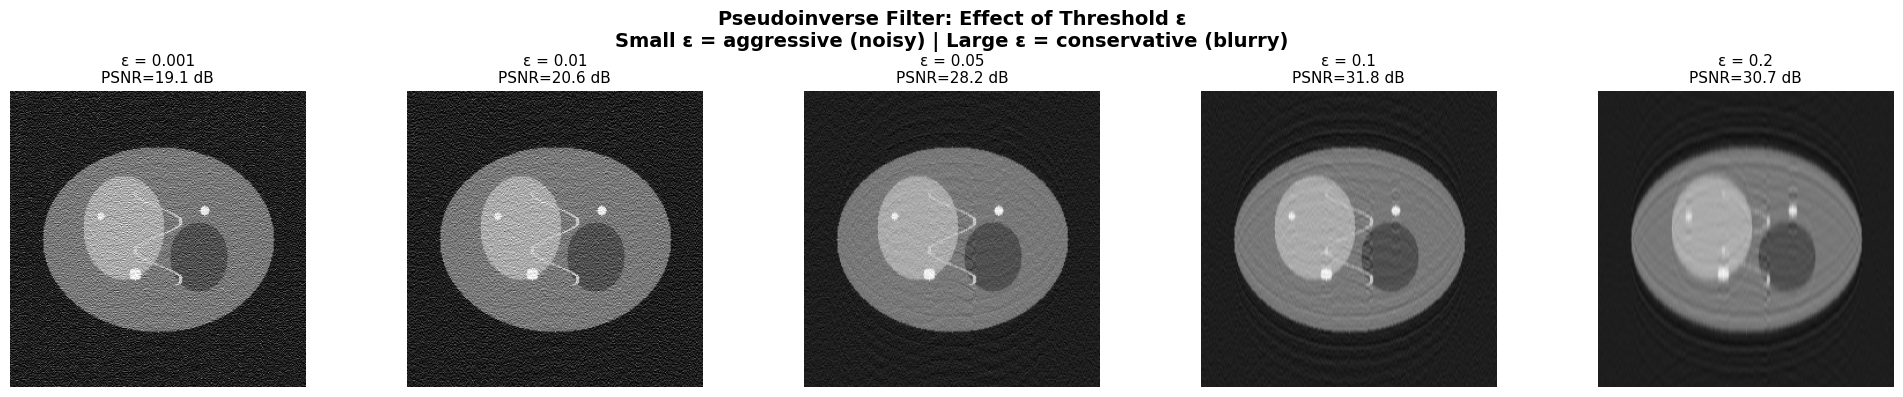

The pseudoinverse is better than naive inverse but still limited.
It does not consider the NOISE STATISTICS in its design.
The Wiener filter (next lesson) optimally balances deblurring and noise.


In [9]:
# Pseudoinverse filter

def pseudoinverse_filter(G, H, epsilon=0.01):
    """
    Pseudoinverse filter: invert H only where |H| > epsilon.
    """
    F_hat = np.zeros_like(G, dtype=complex)
    mask = np.abs(H) > epsilon
    F_hat[mask] = G[mask] / H[mask]
    
    restored = np.real(np.fft.ifft2(np.fft.ifftshift(F_hat)))
    return np.clip(restored, 0, 255)


# Apply with different thresholds
epsilon_values = [0.001, 0.01, 0.05, 0.1, 0.2]

fig, axes = plt.subplots(1, len(epsilon_values), figsize=(20, 4))

for i, eps in enumerate(epsilon_values):
    restored = pseudoinverse_filter(G_n, H_motion, epsilon=eps)
    psnr = compute_psnr(original, restored)
    
    axes[i].imshow(restored, cmap='gray', vmin=0, vmax=255)
    axes[i].set_title(f'ε = {eps}\nPSNR={psnr:.1f} dB', fontsize=11)
    axes[i].axis('off')

plt.suptitle('Pseudoinverse Filter: Effect of Threshold ε\n'
             'Small ε = aggressive (noisy) | Large ε = conservative (blurry)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("The pseudoinverse is better than naive inverse but still limited.")
print("It does not consider the NOISE STATISTICS in its design.")
print("The Wiener filter (next lesson) optimally balances deblurring and noise.")

---
## Summary

What we learned:

1. **Linear, Position-Invariant** degradation enables frequency domain restoration via the model $G = H \cdot F + N$.

2. **Degradation estimation** can be done by observation (point source), experimentation (known input), or mathematical modeling.

3. **Atmospheric turbulence**: $H = e^{-k(u^2+v^2)^{5/6}}$, smooth with no zeros.

4. **Motion blur**: $H = \frac{T}{\pi(ua+vb)}\sin[\pi(ua+vb)]e^{-j\pi(ua+vb)}$, has **zeros** that make inversion impossible.

5. **Naive inverse filtering** ($\hat{F} = G/H$) amplifies noise catastrophically where $H \to 0$. Works only with **zero noise**.

6. **Truncated inverse filtering** limits inversion to a radius $D_0$, reducing noise at the cost of resolution.

7. **Pseudoinverse filtering** skips inversion where $|H| < \epsilon$, but the threshold must be chosen carefully.

8. All inverse-type filters share the same fundamental limitation: they do **not explicitly account for noise statistics**. The Wiener filter addresses this.